# Word2Vec Results Demo

This notebook is for **showing the learned embeddings only**.  
It does **not** include training. It focuses on:

- nearest neighbors
- word analogy
- similarity sanity checks
- PCA
- t-SNE
- cosine similarity heatmap

You can choose where to load `W_center.npy` from in the configuration cell below.


In [13]:
from pathlib import Path
PROJECT_ROOT = Path(".").resolve()
# Option A: point to a run directory, then let the notebook resolve checkpoint paths

RUN_DIR = PROJECT_ROOT / "checkpoints" / "20260316_001008"
RUN_DIR = PROJECT_ROOT / "checkpoints" / "20260315_231058_bestbest"
RUN_DIR = PROJECT_ROOT / "checkpoints" / "20260316_001306"

CHECKPOINT_SUBDIR = "final"   # "final" or "latest"

if not RUN_DIR.exists():
    raise FileNotFoundError(
        f"RUN_DIR does not exist: {RUN_DIR}\n"
        "Please update RUN_DIR to a valid checkpoint run folder."
    )

# Option B: directly point to checkpoint files (overrides RUN_DIR if not None)
W_CENTER_PATH = None
W_CONTEXT_PATH = None

# Which embedding should be used for analysis?
# Options: "center", "context", "average"
EMBEDDING_SOURCE = "average"

In [14]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    import sklearn  # noqa: F401
except Exception as e:
    raise ImportError("This notebook needs scikit-learn. Install it with: pip install scikit-learn") from e

# =========================
# Configuration
# =========================

# How to load vocab?
# Options: "rebuild", "json", "npy", "pkl", "none"
VOCAB_MODE = "json"
VOCAB_PATH = RUN_DIR / "vocab.json"

# If VOCAB_MODE == "rebuild", whether to reuse settings from run_config.json
USE_RUN_CONFIG_FOR_VOCAB = True

# Demo settings
TOP_K = 10
PCA_WORDS = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "paris", "france", "berlin", "germany",
    "london", "england", "rome", "italy",
    "cat", "dog", "horse", "bird",
    "car", "train", "plane", "city",
    "music", "science", "art", "history",
]
TSNE_MAX_WORDS = 250
TSNE_RANDOM_STATE = 42

SHOW_LOSS_CURVE = True

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = C:\Users\User1\OneDrive - TU Eindhoven\Job\JetBrains\Hallucination Detection


Load helper utilities from the companion file next to this notebook.

In [15]:
# =========================
# Keeping them outside the main demo flow makes the notebook easier to present.
# =========================
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from src.eval.demo_helpers import (
    resolve_checkpoint_paths,
    load_run_config,
    load_numpy_embeddings,
    l2_normalize_rows,
    maybe_load_vocab,
    nearest_neighbors,
    analogy,
    similarity_table,
    plot_loss_if_available,
    collect_existing_words,
    plot_pca,
    plot_tsne,
    plot_similarity_heatmap,
    maybe_pick_default_words,
)

Load embeddings and vocab (code hidden)

In [16]:
# =========================
# Load embeddings and vocab
# =========================

W_CENTER_PATH_RESOLVED, W_CONTEXT_PATH_RESOLVED = resolve_checkpoint_paths(
    run_dir=RUN_DIR,
    checkpoint_subdir=CHECKPOINT_SUBDIR,
    w_center_path=W_CENTER_PATH,
    w_context_path=W_CONTEXT_PATH,
)

if not W_CENTER_PATH_RESOLVED.exists():
    raise FileNotFoundError(
        f"Cannot find W_center.npy at: {W_CENTER_PATH_RESOLVED}\n"
        "Please update RUN_DIR or W_CENTER_PATH in the configuration cell."
    )

run_config = load_run_config(RUN_DIR)
W_center, W_context, EMB = load_numpy_embeddings(
    W_CENTER_PATH_RESOLVED,
    W_CONTEXT_PATH_RESOLVED,
    embedding_source=EMBEDDING_SOURCE,
)
EMB_NORM = l2_normalize_rows(EMB)

word2id, id2word = maybe_load_vocab(
    vocab_mode=VOCAB_MODE,
    vocab_path=VOCAB_PATH,
    project_root=PROJECT_ROOT,
    run_config=run_config,
    use_run_config_for_vocab=USE_RUN_CONFIG_FOR_VOCAB,
)

print("Loaded embedding matrices:")
print(f"  W_center: {W_center.shape}")
print(f"  W_context: {None if W_context is None else W_context.shape}")
print(f"  Embedding source: {EMBEDDING_SOURCE}")
print(f"  Final embedding matrix: {EMB.shape}")
print()
print("Loaded vocab:")
print(f"  vocab size = {None if word2id is None else len(word2id)}")

if run_config is not None:
    print()
    print("run_config preview:")
    for k in [
        "embedding_dim",
        "max_vocab_size",
        "min_freq",
        "window_size",
        "num_negative_samples",
        "learning_rate",
        "split",
    ]:
        if k in run_config:
            print(f"  {k}: {run_config[k]}")

Loaded embedding matrices:
  W_center: (10002, 100)
  W_context: (10002, 100)
  Embedding source: average
  Final embedding matrix: (10002, 100)

Loaded vocab:
  vocab size = 10002

run_config preview:
  embedding_dim: 100
  max_vocab_size: 10000
  min_freq: 5
  window_size: 2
  num_negative_samples: 5
  learning_rate: 0.05
  split: train


## Custom queries


Heatmap:


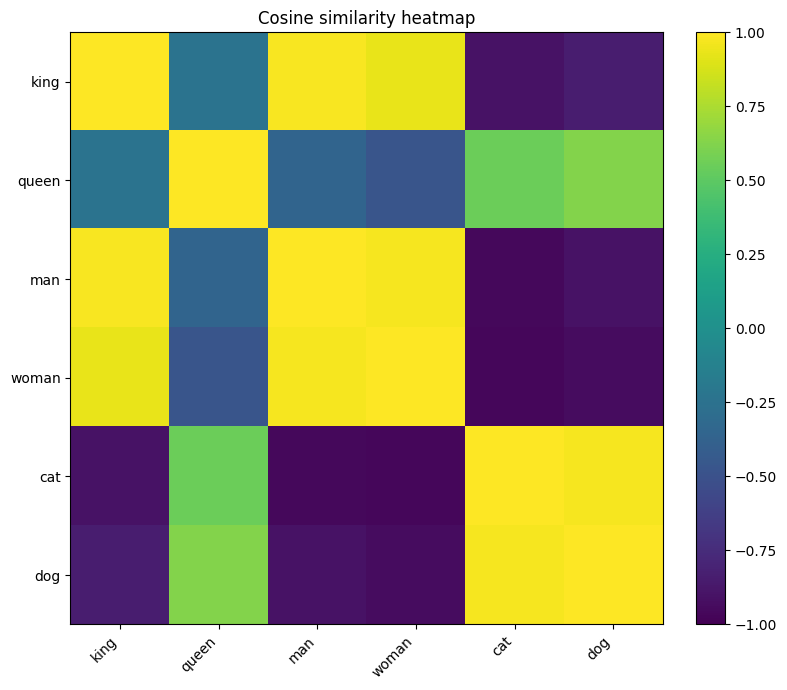

Nearest neighbors for: build



,neighbor,cosine_similarity
0,condemned,0.943283
1,furtado,0.943185
2,nelson,0.942809
3,allen,0.941984
4,jazz,0.941858
5,narrative,0.941830
6,reduce,0.941777
7,acids,0.941536
8,breaking,0.941342
9,excavations,0.941289


In [17]:
# For this checkpoint, "build" gives a slightly more interpretable nearest-neighbor sample than "king".
my_query = "build"
my_analogy = ("man", "king", "woman")
my_heatmap_words = ["king", "queen", "man", "woman", "cat", "dog"]

print("\nHeatmap:")
try:
    plot_similarity_heatmap(my_heatmap_words, EMB, word2id)
except Exception as e:
    print(f"Heatmap failed: {e}")

if word2id is not None and my_query in word2id:
    print(f"Nearest neighbors for: {my_query}\n")
    display(pd.DataFrame(
        nearest_neighbors(
            my_query,
            EMB,
            word2id,
            id2word,
            top_k=TOP_K,
            normalized_embeddings=EMB_NORM,
        ),
        columns=["neighbor", "cosine_similarity"],
    ))
else:
    print(f"Word not found: {my_query}")





## Word analogy

Classic analogy query:

\[
b - a + c \approx ?
\]

Example: `man : king :: woman : queen`


In [18]:
analogy_examples = [
    ("man", "king", "woman"),
    ("paris", "france", "berlin"),
    ("boy", "prince", "girl"),
]

for a, b, c in analogy_examples:
    if word2id is None or any(w not in word2id for w in (a, b, c)):
        print(f"Skip analogy ({a}, {b}, {c}) because at least one word is missing from the vocab.")
        continue

    print(f"\n{a} : {b} :: {c} : ?")
    for word, score in analogy(
        a, b, c, EMB, word2id, id2word, top_k=TOP_K, normalized_embeddings=EMB_NORM
    ):
        print(f"  {word:<18} {score: .4f}")


man : king :: woman : ?
  so                  0.9818
  an                  0.9807
  such                0.9807
  many                0.9806
  now                 0.9804
  up                  0.9802
  that                0.9802
  between             0.9802
  .                   0.9801
  0                   0.9800

paris : france :: berlin : ?
  credits             0.9250
  accolades           0.9236
  etymology           0.9229
  intersections       0.9228
  taxonomy            0.9227
  aftermath           0.9182
  discography         0.9167
  summary             0.9147
  standings           0.9140
  xef                 0.9068

boy : prince :: girl : ?
  ali                 0.8760
  odaenathus          0.8666
  van                 0.8665
  therefore           0.8661
  s.                  0.8643
  ray                 0.8636
  shape               0.8633
  <UNK>               0.8630
  shiva               0.8616
  alongside           0.8601


## Similarity sanity checks

A few hand-picked word pairs can be useful as a quick semantic sanity check.


In [19]:
sanity_pairs = [
    ("cat", "dog"),
    ("car", "train"),
    ("paris", "france"),
    ("king", "queen"),
    ("cat", "democracy"),
    ("music", "science"),
]

sim_df = similarity_table(sanity_pairs, EMB, word2id)
sim_df.sort_values("cosine_similarity", ascending=False)

,word_1,word_2,cosine_similarity
0,cat,dog,0.969792
5,music,science,0.908100
1,car,train,0.773344
4,cat,democracy,0.556383
3,king,queen,-0.235168
2,paris,france,-0.591247


## PCA visualization

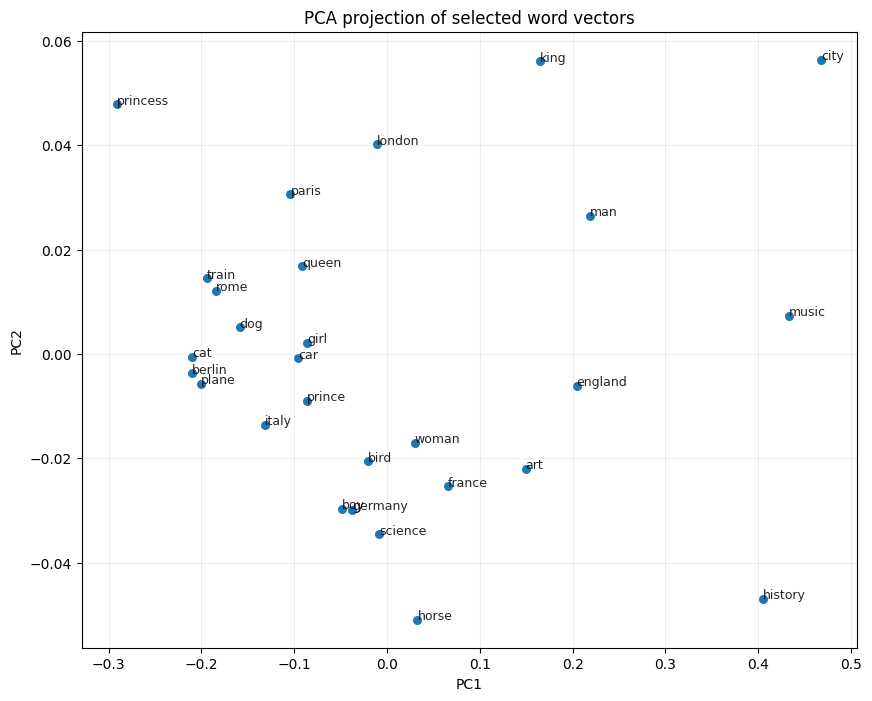

In [20]:
plot_pca(PCA_WORDS, EMB, word2id)

## t-SNE visualization

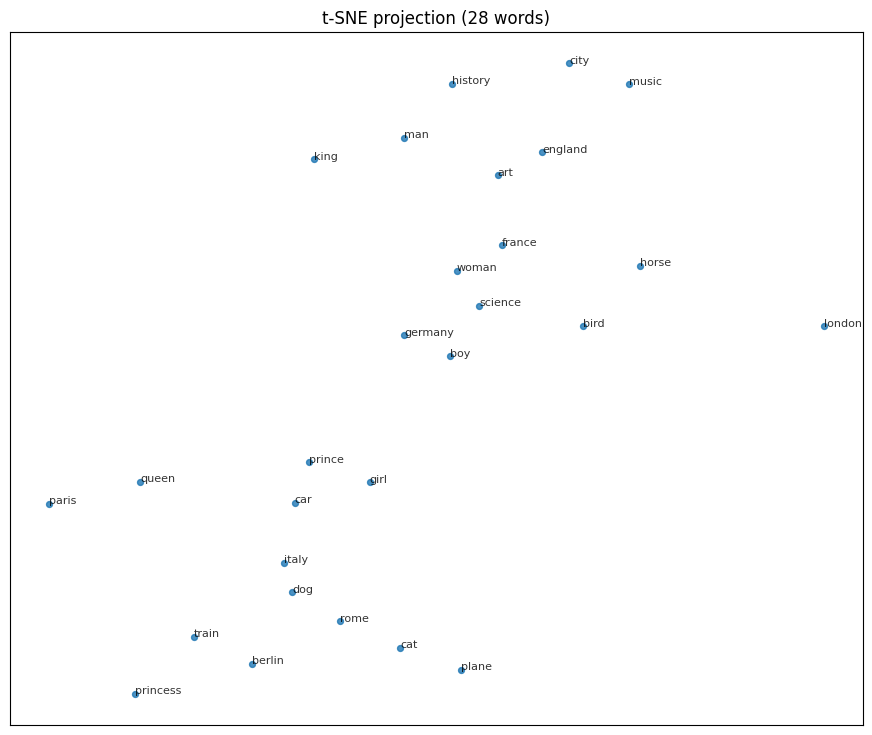

In [21]:
if word2id is None:
    raise ValueError("Need vocab for t-SNE visualization")

candidate_words = collect_existing_words(PCA_WORDS, word2id)
if len(candidate_words) < 20:
    candidate_words = maybe_pick_default_words(id2word, limit=TSNE_MAX_WORDS)

plot_tsne(
    candidate_words,
    EMB,
    word2id,
    max_words=TSNE_MAX_WORDS,
    random_state=TSNE_RANDOM_STATE,
)

## Cosine similarity heatmap

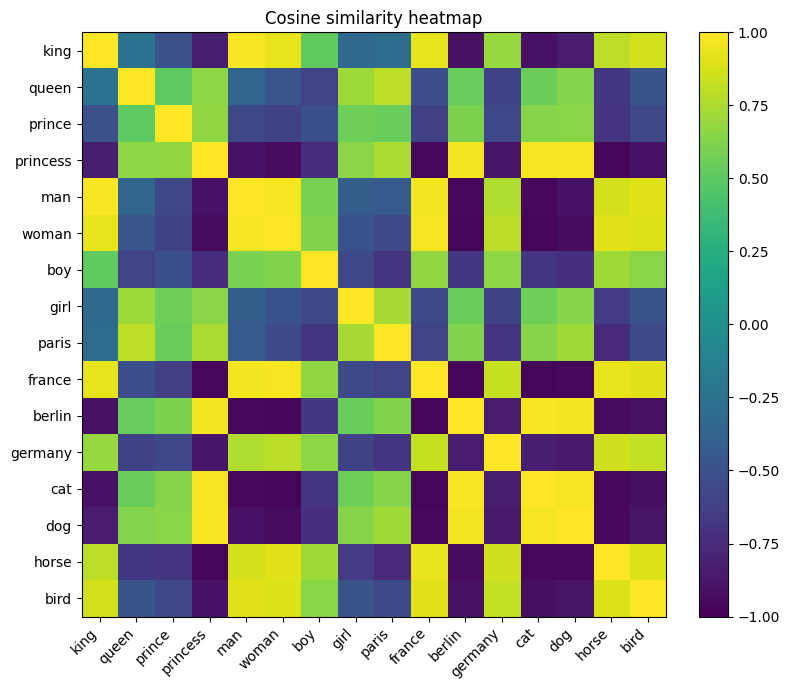

In [22]:
heatmap_words = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "paris", "france", "berlin", "germany",
    "cat", "dog", "horse", "bird",
]
plot_similarity_heatmap(heatmap_words, EMB, word2id)

## Nearest neighbors

This is the simplest qualitative check:  
for a query word, list the top cosine-nearest words in the learned embedding space.


In [23]:
query_words = [
    "king", "queen", "man", "woman",
    "paris", "france", "berlin", "germany",
    "cat", "dog", "music", "science",
]

available_queries = [w for w in query_words if word2id is not None and w in word2id]
if not available_queries:
    print("None of the default query words are in the vocab. Replace query_words with words from your corpus.")
else:
    for q in available_queries:
        print(f"\n[{q}]")
        for neighbor, score in nearest_neighbors(
            q, EMB, word2id, id2word, top_k=TOP_K, normalized_embeddings=EMB_NORM
        ):
            print(f"  {neighbor:<18} {score:.4f}")


[king]
  the                0.9961
  ,                  0.9960
  who                0.9949
  company            0.9949
  described          0.9944
  wrote              0.9943
  small              0.9940
  black              0.9940
  and                0.9938
  any                0.9938

[queen]
  jack               0.8716
  al                 0.8712
  le                 0.8697
  <UNK>              0.8640
  associated         0.8628
  la                 0.8622
  constructed        0.8611
  author             0.8521
  sun                0.8508
  st.                0.8500

[man]
  from               0.9975
  this               0.9974
  his                0.9974
  on                 0.9974
  it                 0.9973
  while              0.9973
  used               0.9972
  also               0.9972
  he                 0.9972
  at                 0.9972

[woman]
  june               0.9841
  7                  0.9837
  6                  0.9835
  much               0.9835
  world        

## Appendix: helper utilities

To keep the demo notebook clean, helper functions are stored in a companion file in `src/` foler:

`demo_helpers.py`

The next cell shows where that file is loaded from.


In [24]:
from pathlib import Path
HELPER_FILE = Path("src/eval/demo_helpers.py").resolve()
print(HELPER_FILE)

C:\Users\User1\OneDrive - TU Eindhoven\Job\JetBrains\Hallucination Detection\src\eval\demo_helpers.py
